# Comment Category Prediction

## Submission By:

- **Name:** Varun Agnihotri
- **Roll Number:** `24f2004142`

## Import all the required libraries

In [1]:
import gc
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from scipy.sparse import csr_matrix, issparse
from sklearn.ensemble import (
    ExtraTreesClassifier,
    RandomForestClassifier,
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

## Config

In [2]:
IS_KAGGLE = "KAGGLE_KERNEL_RUN_TYPE" in os.environ

if IS_KAGGLE:
    DATA_DIR = Path("/kaggle/input/comment-category-prediction-challenge")
else:
    DATA_DIR = Path("datasets/")

# Ensemble top K models
TOP_K = 3

## Data loading

In [3]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(
    DATA_DIR / ("Sample.csv" if IS_KAGGLE else "sample_submission.csv")
)

In [4]:
for _name, _df in [
    ("train", train),
    ("test", test),
    ("sample_sub", sample_sub),
]:
    print(f" {_name} ".center(50, "="))
    print("\nDataset Info:")
    print(_df.info())
    print("\nDataset Description:")
    print(_df.describe(include="all"))
    # print("\nTable Head (10 rows):")
    # print(_df.head(10))
    print("\n\n")

===================== train ======================

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   created_date  198000 non-null  str  
 1   post_id       198000 non-null  int64
 2   emoticon_1    198000 non-null  int64
 3   emoticon_2    198000 non-null  int64
 4   emoticon_3    198000 non-null  int64
 5   upvote        198000 non-null  int64
 6   downvote      198000 non-null  int64
 7   if_1          198000 non-null  int64
 8   if_2          198000 non-null  int64
 9   race          52577 non-null   str  
 10  religion      52577 non-null   str  
 11  gender        52577 non-null   str  
 12  disability    198000 non-null  bool 
 13  comment       197999 non-null  str  
 14  label         198000 non-null  int64
dtypes: bool(1), int64(9), str(5)
memory usage: 21.3 MB
None

Dataset Description:
                            created_d

## Helper Functions

In [5]:
def header(msg: str) -> None:
    """
    Print a formatted header message.
    :param msg: Message to be printed as header.
    :return:
    """
    print("\n" + "=" * 50)
    print(msg.center(50))
    print("=" * 50)

In [6]:
def clean_text(text: str) -> str:
    """
    Clean the input text by removing URLs, special characters, and extra spaces.
    :param text: Input text string.
    :return: Cleaned text string.
    """
    text = str(text).lower()
    text = re.sub(r"http\\S+|www\\S+", "", text)
    text = re.sub(r"[^a-zA-Z0-9\\s]", " ", text)
    text = re.sub(r"\\s+", " ", text).strip()
    return text

In [7]:
def calc_sparsity(matrix) -> float:
    """
    Calculate the sparsity of a given matrix.
    :param matrix: Input matrix (numpy array or sparse matrix).
    :return: Sparsity in percentage.
    """
    total_elements = matrix.shape[0] * matrix.shape[1]
    non_zero_elements = matrix.nnz if issparse(matrix) else np.count_nonzero(matrix)
    sparsity = 1.0 - (non_zero_elements / total_elements)
    return sparsity * 100

## Exploratory Data Analysis

In [8]:
train.shape, test.shape, sample_sub.shape

((198000, 15), (102000, 14), (102000, 2))

In [9]:
train.sample(10)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
3441,2023-12-10 19:40:48.321768+00:00,73,5,0,1,0,1,0,6,NaN,NaN,NaN,False,"lol, actually I kinda like the Donald. He is s...",2
70574,2023-04-15 21:29:08.197688+00:00,40,0,0,0,3,0,6,10,none,none,none,True,It's refreshing to see the mayor's race descri...,2
3546,2023-06-06 20:05:25.822718+00:00,39,0,0,0,10,0,0,5,NaN,NaN,NaN,False,"""We Natives have them beat by their own standa...",0
68710,2024-01-19 20:37:51.575584+00:00,72,0,1,0,5,6,0,5,NaN,NaN,NaN,False,"Yes, anti-democratic acts can lead to violence...",0
197357,2023-06-23 19:52:40.425938+00:00,39,0,0,1,6,3,0,4,NaN,NaN,NaN,False,"Ms.. Patkotak, thank you for this important co...",0
116843,2023-08-13 07:57:52.335883+00:00,72,0,0,1,0,0,0,10,NaN,NaN,NaN,False,"That is the disappointing part, that the press...",2
134948,2023-10-18 23:07:29.735692+00:00,111,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Thanks for your response.Yes, when she and I o...",0
138509,2024-01-10 06:38:20.092202+00:00,39,0,0,0,0,4,0,4,NaN,NaN,NaN,False,If anyone needs voted out it's Les. He wants t...,0
171267,2024-06-02 07:51:26.078561+00:00,31,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"The President of OHSU just retired, after a di...",2
180902,2023-10-08 13:55:48.792894+00:00,72,4,0,0,3,1,4,4,none,none,none,False,Maybe it's better called Trump's Lap dance for...,0


In [10]:
# Label distribution
print(train["label"].value_counts())
print(f"\nProportions:\n{train['label'].value_counts(normalize=True)}")

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64

Proportions:
label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


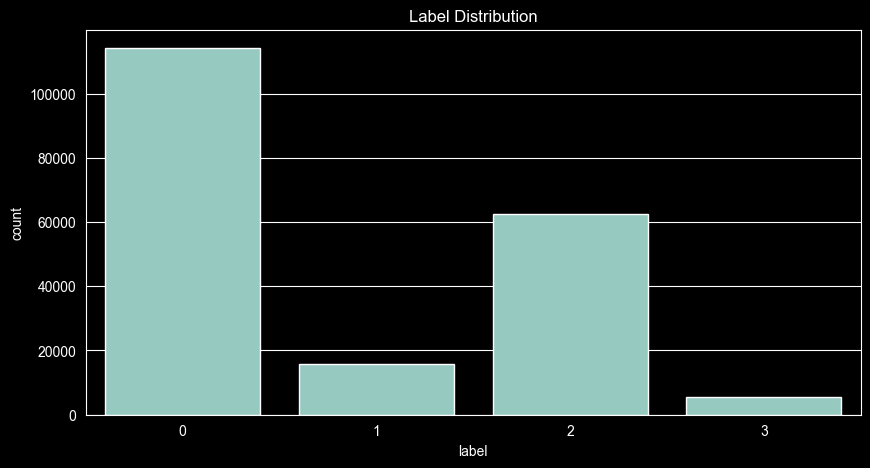

In [11]:
plt.figure(figsize=(10, 5))
sns.countplot(data=train, x="label")
plt.title("Label Distribution")
plt.show()

In [12]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0
label,198000.0,0.793965,0.979808,0.0,0.0,0.0,2.0,3.0


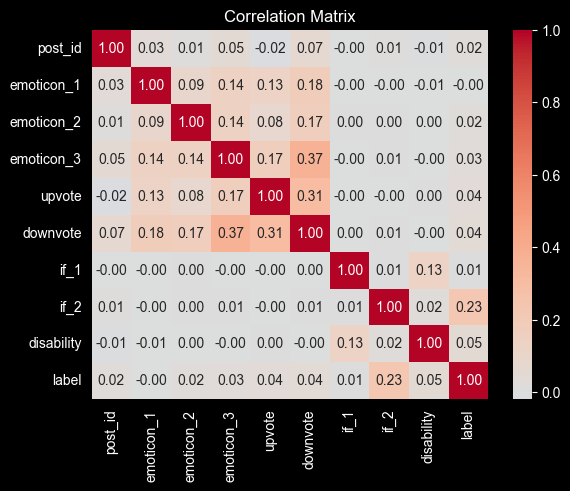

In [13]:
corr = train.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

In [14]:
train["comment_length"] = train["comment"].str.len()
train["word_count"] = train["comment"].str.split().str.len()

header("TEXT STATISTICS BY LABEL")
print(train.groupby("label")[["comment_length", "word_count"]].mean())


             TEXT STATISTICS BY LABEL             
       comment_length  word_count
label                            
0          295.899844   51.187787
1          335.709700   57.233446
2          316.893418   54.901537
3          194.171695   34.978424


## Feature Engineering

In [15]:
def create_features(df):
    df = df.copy()

    # Text features
    df["comment_length"] = df["comment"].str.len()
    df["word_count"] = df["comment"].str.split().str.len()
    df["avg_word_length"] = df["comment"].apply(
        lambda x: np.mean([len(w) for w in str(x).split()]) if str(x).split() else 0
    )

    # Special characters
    df["exclamation_count"] = df["comment"].str.count("!")
    df["question_count"] = df["comment"].str.count("\\?")
    df["capital_ratio"] = df["comment"].apply(
        lambda x: (
            sum(1 for c in str(x) if c.isupper()) / len(str(x))
            if len(str(x)) > 0
            else 0
        )
    )

    # Engagement features
    df["total_votes"] = df["upvote"] + df["downvote"]
    df["vote_ratio"] = np.where(
        df["total_votes"] > 0, df["upvote"] / df["total_votes"], 0.5
    )
    df["vote_diff"] = df["upvote"] - df["downvote"]
    df["log_upvote"] = np.log1p(df["upvote"])
    df["log_downvote"] = np.log1p(df["downvote"])

    # Temporal features
    df["created_date"] = pd.to_datetime(df["created_date"])
    df["hour"] = df["created_date"].dt.hour
    df["day_of_week"] = df["created_date"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["is_night"] = ((df["hour"] >= 22) | (df["hour"] <= 6)).astype(int)

    # Emoticon features
    df["total_emoticons"] = df["emoticon_1"] + df["emoticon_2"] + df["emoticon_3"]

    # Post-level aggregations
    post_stats = (
        df.groupby("post_id")
        .agg({"upvote": ["mean", "count"], "downvote": "mean"})
        .reset_index()
    )

    post_stats.columns = [
        "post_id",
        "post_avg_upvote",
        "post_count",
        "post_avg_downvote",
    ]

    df = df.merge(post_stats, on="post_id", how="left")
    df["upvote_vs_post"] = df["upvote"] - df["post_avg_upvote"]
    df["downvote_vs_post"] = df["downvote"] - df["post_avg_downvote"]

    return df

In [16]:
train = create_features(train)
test = create_features(test)

In [17]:
print(f"Total Features: {len(train.columns)}")

Total Features: 36


## Model Building

In [18]:
train["comment_clean"] = train["comment"].apply(clean_text)
test["comment_clean"] = test["comment"].apply(clean_text)

In [19]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2), min_df=3, max_df=0.9)

In [20]:
tfidf_train = tfidf.fit_transform(train["comment_clean"])
tfidf_test = tfidf.transform(test["comment_clean"])

In [21]:
feature_cols = train.select_dtypes(include="number").columns.tolist()
feature_cols.remove("label")

In [22]:
X_tab = train[feature_cols].fillna(0)
X_tab_test = test[feature_cols].fillna(0)

In [23]:
scaler = StandardScaler()
X_tab_scaled = scaler.fit_transform(X_tab)
X_tab_test_scaled = scaler.transform(X_tab_test)

In [24]:
# Combine features
X = np.hstack([tfidf_train.toarray(), X_tab_scaled])
X_sub = np.hstack([tfidf_test.toarray(), X_tab_test_scaled])
y = train["label"].values

print(f"Training shape: {X.shape}")

Training shape: (198000, 2029)


In [25]:
# # Cross-validation
# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# n_classes = train["label"].unique().shape[0]
# xgb_preds = np.zeros(len(X_test))
# lgb_preds = np.zeros(len(X_test))
#
# n_splits = skf.get_n_splits()

In [26]:
# xgb_test_preds = np.zeros((X_test.shape[0], n_classes))
# lgb_test_preds = np.zeros((X_test.shape[0], n_classes))
#
# oof_preds = np.zeros((X_train.shape[0], n_classes))
# for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
#     print(f"Fold {fold + 1}:")
#
#     X_tr, X_val = X_train[tr_idx], X_train[val_idx]
#     y_tr, y_val = y_train[tr_idx], y_train[val_idx]
#
#     # XGBoost
#     xgb = XGBClassifier(
#         n_estimators=300,
#         max_depth=6,
#         early_stopping_rounds=50,
#         learning_rate=0.05,
#         random_state=42,
#     )
#     xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#     xgb_val_probs = xgb.predict_proba(X_val)
#     xgb_test_preds += xgb.predict_proba(X_test) / n_splits
#
#     # LightGBM
#     lgb = LGBMClassifier(
#         n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1
#     )
#     lgb.fit(X_tr, y_tr)
#     lgb_val_probs = lgb.predict_proba(X_val)
#     lgb_test_preds += lgb.predict_proba(X_test) / n_splits
#
#     val_ensemble_probs = (0.5 * xgb_val_probs) + (0.5 * lgb_val_probs)
#     val_ensemble_preds = np.argmax(val_ensemble_probs, axis=1)
#     val_acc = accuracy_score(y_val, val_ensemble_preds)
#     print(f"\tAccuracy: {val_acc:.4f}")

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
header("Converting Datasets to Sparse Matrices")

print("Train Dataset:")
print(f"\tSparsity: {calc_sparsity(X_train):.2f}%")
print(f"\tOriginal size: {X_train.nbytes / 1e6:.2f} MB")
X_train = csr_matrix(X_train.astype("float32"))
print(f"\tSparse size: {X_train.data.nbytes / 1e6:.2f} MB")

print("\nTest Dataset:")
print(f"\tSparsity: {calc_sparsity(X_test):.2f}%")
print(f"\tOriginal size: {X_test.nbytes / 1e6:.2f} MB")
X_test = csr_matrix(X_test.astype("float32"))
print(f"\tSparse size: {X_test.data.nbytes / 1e6:.2f} MB")

# Cleanup
gc.collect()


      Converting Datasets to Sparse Matrices      
Train Dataset:
	Sparsity: 96.82%
	Original size: 2571.15 MB
	Sparse size: 40.94 MB

Test Dataset:
	Sparsity: 96.82%
	Original size: 642.79 MB
	Sparse size: 10.22 MB


0

In [29]:
models = {
    # Gradient Boosting Models
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        objective="multi:softmax",
        num_class=4,
        scale_pos_weight=1,
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        random_state=42,
        verbose=-1,
        class_weight="balanced",
    ),
    # "HistGradientBoosting": HistGradientBoostingClassifier(
    #     max_iter=300,
    #     max_depth=6,
    #     learning_rate=0.05,
    #     random_state=42,
    #     class_weight="balanced",
    # ),
    # Tree-Based Ensemble Models
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=10,
        random_state=42,
        class_weight="balanced",
        n_jobs=-1,
    ),
    # Linear Models
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
        solver="lbfgs",
    ),
    # Neural Network
    "MLP": MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

In [30]:
scores = {}

for model_name, model in models.items():
    header(f"Training {model_name}")
    if model_name == "XGBoost":
        sample_weights = compute_sample_weight("balanced", y_train)
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)

    val_preds = model.predict(X_test)

    score = f1_score(y_test, val_preds, average="macro")
    scores[model_name] = {
        "score": score,
        "model": model,
    }
    print(f"\t{model_name} Macro F1 Score: {score:.4f}")


                 Training XGBoost                 


V:\Codes\IITM-BS\MLP_Project\Comment Category Prediction Challenge\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [00:20:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


	XGBoost Macro F1 Score: 0.7241

                Training LightGBM                 


V:\Codes\IITM-BS\MLP_Project\Comment Category Prediction Challenge\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


	LightGBM Macro F1 Score: 0.7376

              Training RandomForest               
	RandomForest Macro F1 Score: 0.6278

               Training ExtraTrees                
	ExtraTrees Macro F1 Score: 0.4566

           Training LogisticRegression            
	LogisticRegression Macro F1 Score: 0.7292

                   Training MLP                   
	MLP Macro F1 Score: 0.7659


In [31]:
# sort scores
scores = list(sorted(scores.items(), key=lambda x: x[1]["score"], reverse=True))

## Hyperparameter Tuning

In [32]:
params_dict = {
    # Gradient Boosting Models
    "XGBoost": {
        "n_estimators": [200, 300, 500],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_child_weight": [1, 5, 10],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
    },
    "LightGBM": {
        "n_estimators": [200, 300, 500],
        "num_leaves": [31, 63, 127],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_child_samples": [10, 20, 50],
        "subsample": [0.7, 0.8, 0.9],
        "colsample_bytree": [0.7, 0.8, 0.9],
        "class_weight": ["balanced", None],
    },
    "HistGradientBoosting": {
        "max_iter": [200, 300, 500],
        "max_depth": [5, 7, 10, None],
        "learning_rate": [0.01, 0.05, 0.1],
        "min_samples_leaf": [10, 20, 50],
        "l2_regularization": [0, 0.1, 1],
        "class_weight": ["balanced", None],
    },
    # Tree-Based Ensemble Models
    "RandomForest": {
        "n_estimators": [200, 300, 500],
        "max_depth": [10, 15, 20, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.3],
        "class_weight": ["balanced", "balanced_subsample"],
    },
    "ExtraTrees": {
        "n_estimators": [200, 300, 500],
        "max_depth": [10, 15, 20, None],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", 0.3],
        "class_weight": ["balanced", "balanced_subsample"],
    },
    # Linear Models
    "LogisticRegression": {
        "C": [0.01, 0.1, 1, 10],
        "class_weight": ["balanced", None],
    },
    # Neural Network
    "MLP": {
        "hidden_layer_sizes": [(64, 32), (128, 64), (128, 64, 32)],
        "alpha": [0.0001, 0.001, 0.01],
        "learning_rate_init": [0.001, 0.01],
        "batch_size": [64, 128, 256],
    },
}

In [33]:
for model_name, model_data in scores[:3]:
    header(f"Hyperparameter Tuning for {model_name}")

    fit_params = {}
    if model_name == "XGBoost":
        weights = compute_sample_weight("balanced", y_train)
        fit_params["sample_weight"] = weights

    search_cv = RandomizedSearchCV(
        estimator=models[model_name],
        param_distributions=params_dict[model_name],
        n_iter=10,
        scoring="f1_macro",
        cv=3,
        verbose=3,
        random_state=42,
        n_jobs=-1,
    )

    search_cv.fit(X_train, y_train, **fit_params)
    scores.append(
        (
            f"{model_name}_Tuned",
            {
                "score": search_cv.best_score_,
                "model": search_cv.best_estimator_,
            },
        )
    )

    print(f"\t{model_name}_Tuned Best Score: {search_cv.best_score_:.4f}")


          Hyperparameter Tuning for MLP           
Fitting 3 folds for each of 10 candidates, totalling 30 fits
	MLP_Tuned Best Score: 0.7698

        Hyperparameter Tuning for LightGBM        
Fitting 3 folds for each of 10 candidates, totalling 30 fits
	LightGBM_Tuned Best Score: 0.7641

   Hyperparameter Tuning for LogisticRegression   
Fitting 3 folds for each of 8 candidates, totalling 24 fits


V:\Codes\IITM-BS\MLP_Project\Comment Category Prediction Challenge\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


	LogisticRegression_Tuned Best Score: 0.7561


In [34]:
# sort scores
scores = list(sorted(scores, key=lambda x: x[1]["score"], reverse=True))

## Ensemble Models

In [ ]:
classes = np.unique(y)
test_probs = np.zeros((X_test.shape[0], len(np.unique(y))))
for model_name, model_data in scores[:TOP_K]:
    header(f"Ensemble Model: {model_name}")
    print(f"Macro F1 Score: {model_data['score']:.4f}")

    model = model_data["model"]
    test_probs += model.predict_proba(X_test) / TOP_K
    classes = model.classes_

In [ ]:
header("Ensemble Model Results")
ensemble_pred_indices = np.argmax(test_probs, axis=1)
ensemble_preds = classes[ensemble_pred_indices]  # type: ignore

ensemble_score = f1_score(y_test, ensemble_preds, average="macro")

print(f"Ensemble Macro F1 Score: {ensemble_score:.4f}")

print("\nEnsemble Classification Report:")
print(classification_report(y_test, ensemble_preds))

## Predicting Test Data

In [ ]:
best_model_name, best_model_data = scores[0]

if ensemble_score > best_model_data["score"]:
    # Use ensemble model
    final_probs = np.zeros((X_sub.shape[0], len(np.unique(y))))
    print("Generating Ensemble submission...")
    header("Retraining Top Models on Full Data")
    for model_name, model_data in scores[:TOP_K]:
        print(f"Retraining {model_name}...")
        print(f"Macro F1 Score: {model_data['score']:.4f}")

        print("\nRetraining on full training data...")
        model = model_data["model"]

        if "XGBoost" in model_name:
            sample_weights = compute_sample_weight("balanced", y)
            model.fit(X, y, sample_weight=sample_weights)
        else:
            model.fit(X, y)

        # Final predictions
        model_preds = model.predict_proba(X_sub)
        final_probs += model_preds * (1 / TOP_K)
else:
    # Use single best model
    print(
        f"Ensemble score ({ensemble_score:.4f}) did not beat single best model ({best_model_data['score']:.4f})."
    )

    header(f"Best Model: {best_model_name}")
    print(f"Macro F1 Score: {best_model_data['score']:.4f}")

    print("\nClassification Report:")
    best_val_preds = best_model_data["model"].predict(X_test)
    print(classification_report(y_test, best_val_preds))

    print("\nRetraining on full training data...")
    model = best_model_data["model"]

    if best_model_name == "XGBoost":
        sample_weights = compute_sample_weight("balanced", y)
        model.fit(X, y, sample_weight=sample_weights)
    else:
        model.fit(X, y)

    final_probs = model.predict_proba(X_sub)

# Final predictions
final_pred_indices = np.argmax(final_probs, axis=1)
final_preds = classes[final_pred_indices]
print("Final submission generated.")

## Final Submission

In [36]:
submission = pd.DataFrame({"ID": test.index + 1, "label": final_preds})
submission.to_csv("submission.csv", index=False)

header("Submission created!")
print(submission["label"].value_counts())


               Submission created!                
label
0    57495
2    33956
1     8560
3     1989
Name: count, dtype: int64
